# PointNet v2 : Adding Input T-Net

(architecture upgrade — v1 baseline + 3x3 spatial transformer)

## Environment, imports and reproducibility



In [1]:
import os
import time
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from torch.utils.data import Dataset, DataLoader

# Reproducibility — fixed seeds so re-running gives the same numbers
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# Pick the best device available: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

PyTorch version : 2.12.0
Device          : mps


## Loading the pre-sampled point clouds (cache from v1)

In [2]:
# Find the project root no matter where Jupyter is launched from
_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd

DATA_DIR       = os.path.join(PROJECT_ROOT, "data", "ModelNet10")
CACHE_DIR      = os.path.join(PROJECT_ROOT, "data", "cache_1024pts")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Class list (alphabetical = deterministic labels across runs and notebooks)
CLASSES = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}


class CachedModelNet10(Dataset):
    """Reads pre-sampled point clouds from the .npz cache built in v1 notebook."""
    def __init__(self, cache_path):
        data = np.load(cache_path)
        self.points = data["points"]   # (n, 1024, 3) float32
        self.labels = data["labels"]   # (n,) int64

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.points[idx]), int(self.labels[idx])


BATCH_SIZE = 32

train_cached = CachedModelNet10(os.path.join(CACHE_DIR, "train.npz"))
test_cached  = CachedModelNet10(os.path.join(CACHE_DIR, "test.npz"))

train_loader = DataLoader(train_cached, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_loader  = DataLoader(test_cached,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train : {len(train_cached)} samples, {len(train_loader)} batches")
print(f"Test  : {len(test_cached)} samples, {len(test_loader)} batches")
print(f"Classes ({len(CLASSES)}): {CLASSES}")

# Quick smoke test
pts, lbls = next(iter(train_loader))
print(f"\nOne batch -> points {tuple(pts.shape)}, labels {tuple(lbls.shape)}")

Train : 3991 samples, 124 batches
Test  : 908 samples, 29 batches
Classes (10): ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']

One batch -> points (32, 1024, 3), labels (32,)


## Defining the T-Net 

In [3]:
class TNet(nn.Module):
    """Spatial transformer for point clouds. Predicts a k×k affine matrix
    from the input via a mini-PointNet (shared MLP -> max-pool -> FC).
    Initialized to output identity so the model behaves like plain PointNet at init.
    """
    def __init__(self, k=3):
        super().__init__()
        self.k = k
        self.shared_mlp = nn.Sequential(
            nn.Conv1d(k,   64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  128,  1), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,  k * k),
        )
        # Identity-init: zero the final weights, set bias to vec(I_k)
        nn.init.zeros_(self.head[-1].weight)
        nn.init.zeros_(self.head[-1].bias)
        with torch.no_grad():
            self.head[-1].bias.copy_(torch.eye(k).flatten())

    def forward(self, x):
        # x: (B, N, k) -> (B, k, N) for Conv1d
        B = x.size(0)
        x = x.transpose(1, 2)
        x = self.shared_mlp(x)              # (B, 1024, N)
        x = torch.max(x, dim=2)[0]          # (B, 1024)
        x = self.head(x)                    # (B, k*k)
        return x.view(B, self.k, self.k)    # (B, k, k)


# Sanity check: at init, T-Net should output the identity matrix for any input
_tnet = TNet(k=3)
with torch.no_grad():
    T = _tnet(torch.randn(2, 1024, 3))
print("T-Net output at init (should be identity for each batch item):")
print(T[0].numpy().round(4))
print(f"\nT-Net parameter count: {sum(p.numel() for p in _tnet.parameters()):,}")

T-Net output at init (should be identity for each batch item):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

T-Net parameter count: 803,081


## Defining PointNet v2 (v1 + the T-Net)

In [4]:
class PointNetV2(nn.Module):
    """PointNet v2: v1 + input T-Net (3×3 spatial transform of the input)."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.input_tnet = TNet(k=3)
        self.shared_mlp = nn.Sequential(
            nn.Conv1d(3,   64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  128,  1), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,  num_classes),
        )

    def forward(self, x):
        # x: (B, N, 3) — apply the learned 3x3 transform first
        T = self.input_tnet(x)              # (B, 3, 3)
        x = torch.bmm(x, T)                 # (B, N, 3) — multiply each point by T
        x = x.transpose(1, 2)               # (B, 3, N)
        x = self.shared_mlp(x)              # (B, 1024, N)
        x = torch.max(x, dim=2)[0]          # (B, 1024) — global max-pool
        x = self.classifier(x)              # (B, num_classes)
        return x


# Instantiate and inspect
model = PointNetV2(num_classes=10)
n_tnet       = sum(p.numel() for p in model.input_tnet.parameters())
n_mlp        = sum(p.numel() for p in model.shared_mlp.parameters())
n_classifier = sum(p.numel() for p in model.classifier.parameters())
n_total      = sum(p.numel() for p in model.parameters())

print("Model: PointNet v2 (v1 + input T-Net)\n")
print("Parameter count by block:")
print(f"  input T-Net (mini-PointNet) : {n_tnet:>9,}")
print(f"  shared per-point MLP        : {n_mlp:>9,}")
print(f"  classifier head             : {n_classifier:>9,}")
print(f"  {'-'*46}")
print(f"  total                       : {n_total:>9,}    ({n_total/811914:.2f}x v1)")

# Forward sanity on one real batch on the chosen device
model = model.to(device)
pts, lbls = next(iter(train_loader))
pts, lbls = pts.to(device), lbls.to(device)
with torch.no_grad():
    out = model(pts)
print(f"\nForward sanity:")
print(f"  input  shape : {tuple(pts.shape)}")
print(f"  output shape : {tuple(out.shape)}  (expected (32, 10))")
print(f"  finite?      : {torch.isfinite(out).all().item()}")

Model: PointNet v2 (v1 + input T-Net)

Parameter count by block:
  input T-Net (mini-PointNet) :   803,081
  shared per-point MLP        :   151,680
  classifier head             :   660,234
  ----------------------------------------------
  total                       : 1,614,995    (1.99x v1)

Forward sanity:
  input  shape : (32, 1024, 3)
  output shape : (32, 10)  (expected (32, 10))
  finite?      : True


## Training v2 for 20 epochs

Training PointNet v2 (v1 + input T-Net) -- 20 epochs on mps

epoch   train_loss   train_acc    val_acc     time
-------------------------------------------------------
    1       0.4360      0.8619     0.8987    49.4s  *
    2       0.2500      0.9156     0.7698    44.0s
    3       0.2184      0.9211     0.8040    44.0s
    4       0.1895      0.9383     0.8767    44.1s
    5       0.1616      0.9425     0.8447    44.3s
    6       0.1327      0.9491     0.8436    44.9s
    7       0.1564      0.9415     0.8855    45.3s
    8       0.1339      0.9521     0.8932    44.7s
    9       0.1316      0.9529     0.7919    49.7s
   10       0.1109      0.9619     0.9119    48.0s  *
   11       0.1081      0.9602     0.8645    50.6s
   12       0.0959      0.9640     0.8899    47.2s
   13       0.1141      0.9582     0.8921    47.1s
   14       0.0957      0.9688     0.8987    45.8s
   15       0.0843      0.9677     0.8689    44.2s
   16       0.0916      0.9670     0.8778    44.2s
   17     

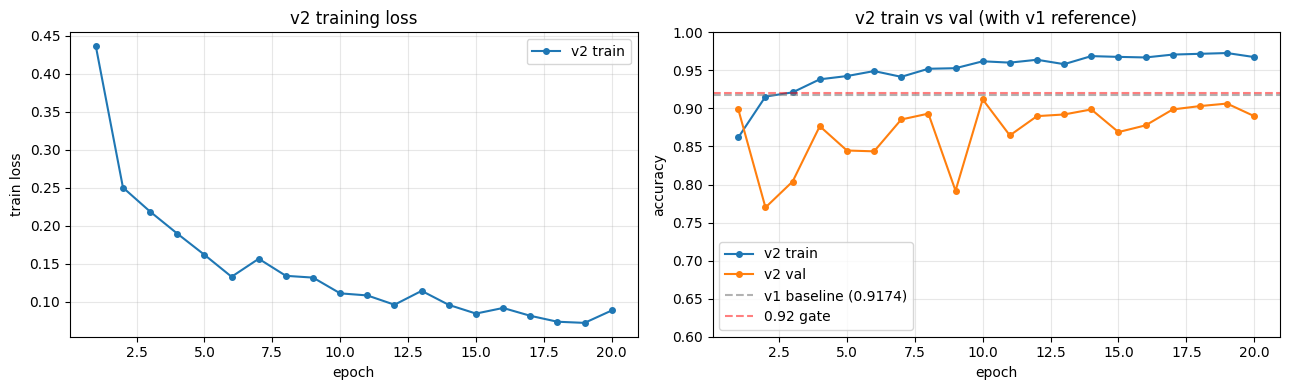

In [5]:
best_path_v2 = os.path.join(CHECKPOINT_DIR, "pointnet_v2_best.pt")

# Fresh model + optimizer (the warm-up forward above doesn't matter — re-instantiate)
model = PointNetV2(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 20
history_v2 = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc_v2 = 0.0

print(f"Training PointNet v2 (v1 + input T-Net) -- {NUM_EPOCHS} epochs on {device}\n")
print(f"{'epoch':>5}  {'train_loss':>11}  {'train_acc':>10}  {'val_acc':>9}  {'time':>7}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ---- Train ----
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader:
        pts, lbls = pts.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(pts)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * pts.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += pts.size(0)
    train_loss = loss_sum / total
    train_acc  = correct  / total

    # ---- Validate ----
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for pts, lbls in test_loader:
            pts, lbls = pts.to(device), lbls.to(device)
            val_correct += (model(pts).argmax(1) == lbls).sum().item()
            val_total   += pts.size(0)
    val_acc = val_correct / val_total

    history_v2["train_loss"].append(train_loss)
    history_v2["train_acc"].append(train_acc)
    history_v2["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc_v2:
        best_val_acc_v2 = val_acc
        torch.save(model.state_dict(), best_path_v2)
        flag = "  *"

    print(f"{epoch:>5}  {train_loss:>11.4f}  {train_acc:>10.4f}  {val_acc:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\n=== Comparison vs v1 ===")
print(f"  v1 baseline       best val_acc: 0.9174")
print(f"  v2 (+ input T-Net) best val_acc: {best_val_acc_v2:.4f}   (delta {best_val_acc_v2 - 0.9174:+.4f})")
print(f"\nCheckpoint: {best_path_v2}")

# Plot curves with v1 baseline as reference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, NUM_EPOCHS + 1)
ax1.plot(ep, history_v2["train_loss"], "-o", markersize=4, label="v2 train")
ax1.set(xlabel="epoch", ylabel="train loss", title="v2 training loss")
ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(ep, history_v2["train_acc"], "-o", markersize=4, label="v2 train")
ax2.plot(ep, history_v2["val_acc"],   "-o", markersize=4, label="v2 val")
ax2.axhline(0.9174, color="gray", linestyle="--", alpha=0.6, label="v1 baseline (0.9174)")
ax2.axhline(0.92,   color="red",  linestyle="--", alpha=0.5, label="0.92 gate")
ax2.set(xlabel="epoch", ylabel="accuracy", title="v2 train vs val (with v1 reference)", ylim=(0.6, 1.0))
ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()

## Per-class evaluation of v2

OVERALL METRICS -- v2 (v1 + input T-Net)
  Accuracy     : 0.9119   (v1 was 0.9174, delta -0.0055)
  Macro F1     : 0.9096   (v1 was 0.9125)
  Weighted F1  : 0.9111   (v1 was 0.9183)

PER-CLASS METRICS
              precision    recall  f1-score   support

     bathtub     0.9608    0.9800    0.9703        50
         bed     0.9429    0.9900    0.9659       100
       chair     0.9899    0.9800    0.9849       100
        desk     0.7442    0.7442    0.7442        86
     dresser     0.7959    0.9070    0.8478        86
     monitor     0.9703    0.9800    0.9751       100
 night_stand     0.8500    0.7907    0.8193        86
        sofa     0.9434    1.0000    0.9709       100
       table     0.9059    0.7700    0.8324       100
      toilet     1.0000    0.9700    0.9848       100

    accuracy                         0.9119       908
   macro avg     0.9103    0.9112    0.9096       908
weighted avg     0.9128    0.9119    0.9111       908

CLASS COVERAGE CHECK
  Distinct classes 

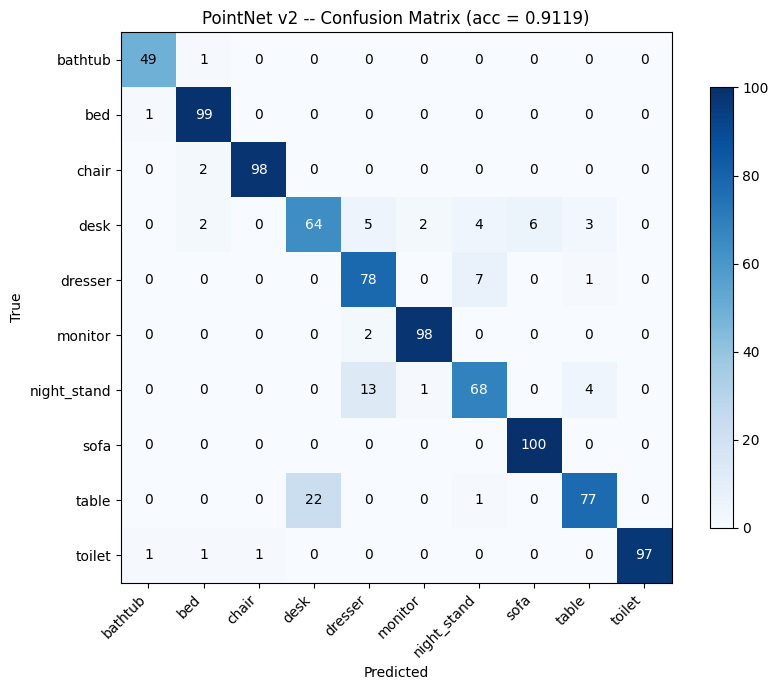

In [6]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_recall_fscore_support,
)

# Load best v2 checkpoint
model = PointNetV2(num_classes=10).to(device)
model.load_state_dict(torch.load(best_path_v2, map_location=device, weights_only=True))
model.eval()

# Inference on full test set
all_preds, all_labels = [], []
with torch.no_grad():
    for pts, lbls in test_loader:
        pts = pts.to(device)
        preds = model(pts).argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(lbls.numpy())
all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# ---- 1. Overall metrics ----
acc         = accuracy_score(all_labels, all_preds)
macro_f1    = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("=" * 55)
print("OVERALL METRICS -- v2 (v1 + input T-Net)")
print("=" * 55)
print(f"  Accuracy     : {acc:.4f}   (v1 was 0.9174, delta {acc - 0.9174:+.4f})")
print(f"  Macro F1     : {macro_f1:.4f}   (v1 was 0.9125)")
print(f"  Weighted F1  : {weighted_f1:.4f}   (v1 was 0.9183)")

# ---- 2. Per-class table ----
print("\n" + "=" * 55)
print("PER-CLASS METRICS")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

# ---- 3. Class coverage check ----
predicted_classes = set(all_preds.tolist())
missing = set(range(10)) - predicted_classes
print("=" * 55)
print("CLASS COVERAGE CHECK")
print("=" * 55)
print(f"  Distinct classes predicted: {len(predicted_classes)}/10")
if missing:
    print(f"  MISSING: {[CLASSES[i] for i in sorted(missing)]}")
    print(f"  GATE FAILED")
else:
    print(f"  GATE PASSED")

# ---- 4. v1 vs v2 per-class F1 comparison ----
v1_f1 = {
    "bathtub": 0.8750, "bed": 0.9043, "chair": 0.9900, "desk": 0.8712,
    "dresser": 0.8324, "monitor": 0.9796, "night_stand": 0.7933,
    "sofa": 0.9899, "table": 0.9048, "toilet": 0.9848,
}
_, _, v2_f1_array, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=list(range(10)), zero_division=0
)

print("\n" + "=" * 55)
print("PER-CLASS F1 -- v1 vs v2 (positive delta = T-Net helped)")
print("=" * 55)
print(f"  {'class':<14}{'v1 F1':>10}{'v2 F1':>10}{'delta':>10}")
print(f"  {'-'*44}")
for i, c in enumerate(CLASSES):
    print(f"  {c:<14}{v1_f1[c]:>10.4f}{v2_f1_array[i]:>10.4f}{v2_f1_array[i] - v1_f1[c]:>+10.4f}")

# ---- 5. Confusion matrix ----
cm = confusion_matrix(all_labels, all_preds, labels=list(range(10)))
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"PointNet v2 -- Confusion Matrix (acc = {acc:.4f})")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

## v2 + augmentation

Train (augmented): 3991 samples, 124 batches
Test  (clean)    : 908 samples, 29 batches


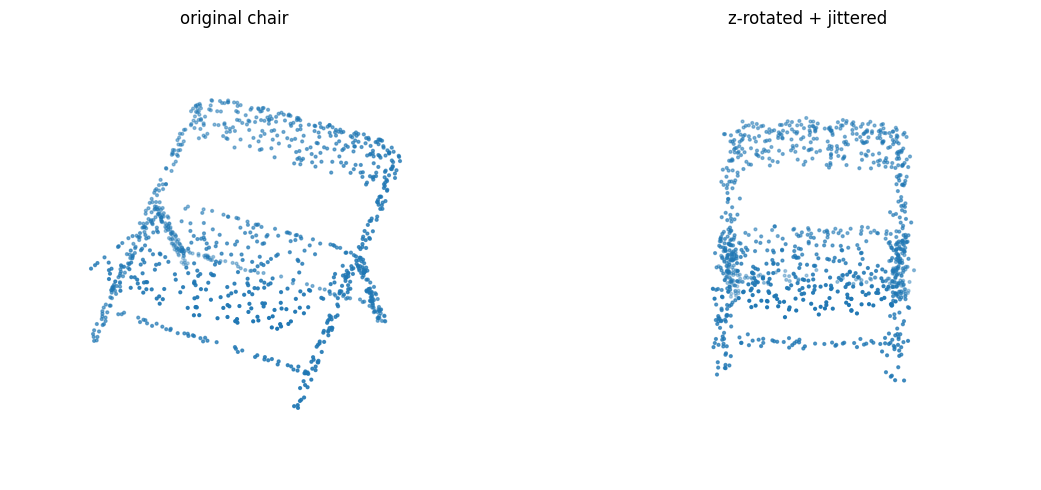

In [7]:
class AugmentedCachedModelNet10(Dataset):
    """Cached ModelNet10 with optional on-the-fly augmentation.
    augment=True applies random z-rotation + per-point Gaussian jitter to train data.
    """
    def __init__(self, cache_path, augment=False, jitter_sigma=0.02, jitter_clip=0.05):
        data = np.load(cache_path)
        self.points = data["points"]
        self.labels = data["labels"]
        self.augment = augment
        self.jitter_sigma = jitter_sigma
        self.jitter_clip = jitter_clip

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        pts = self.points[idx].copy()
        if self.augment:
            # 1. Random rotation around z-axis
            theta = np.random.uniform(0, 2 * np.pi)
            c, s = np.cos(theta), np.sin(theta)
            R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
            pts = pts @ R.T
            # 2. Per-point Gaussian jitter, clipped
            jitter = np.random.normal(0, self.jitter_sigma, pts.shape).astype(np.float32)
            jitter = np.clip(jitter, -self.jitter_clip, self.jitter_clip)
            pts = pts + jitter
        return torch.from_numpy(pts), int(self.labels[idx])


# Augmented train + clean test
train_aug   = AugmentedCachedModelNet10(os.path.join(CACHE_DIR, "train.npz"), augment=True)
test_clean  = AugmentedCachedModelNet10(os.path.join(CACHE_DIR, "test.npz"),  augment=False)

train_loader = DataLoader(train_aug,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_loader  = DataLoader(test_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train (augmented): {len(train_aug)} samples, {len(train_loader)} batches")
print(f"Test  (clean)    : {len(test_clean)} samples, {len(test_loader)} batches")

# Visualize one chair with and without augmentation
chair_idx = int(np.where(train_aug.labels == 2)[0][0])
pts_orig = train_aug.points[chair_idx].copy()
np.random.seed(7)
pts_augd, _ = train_aug[chair_idx]
pts_augd = pts_augd.numpy()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(pts_orig[:, 0], pts_orig[:, 1], pts_orig[:, 2], s=4)
ax1.set_title("original chair"); ax1.set_axis_off()
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(pts_augd[:, 0], pts_augd[:, 1], pts_augd[:, 2], s=4)
ax2.set_title("z-rotated + jittered"); ax2.set_axis_off()
plt.tight_layout(); plt.show()

## Train v2 with augmentation enabled

Training PointNet v2 + augmentation -- 20 epochs on mps
Augmentations: random z-rotation + per-point jitter (sigma=0.02, clip=0.05)

epoch   train_loss   train_acc    val_acc     time
-------------------------------------------------------
    1       0.7288      0.7477     0.7852    48.0s  *
    2       0.4541      0.8422     0.8007    47.5s  *
    3       0.3954      0.8543     0.8337    45.4s  *
    4       0.3570      0.8712     0.8150    46.9s
    5       0.3314      0.8873     0.8161    46.9s
    6       0.3171      0.8889     0.8007    45.7s
    7       0.2836      0.8962     0.7852    45.1s
    8       0.2802      0.8979     0.8645    45.1s  *
    9       0.2740      0.9012     0.8535    44.9s
   10       0.2453      0.9108     0.8139    44.8s
   11       0.2542      0.9060     0.8161    49.6s
   12       0.2408      0.9181     0.8326    45.1s
   13       0.2188      0.9183     0.8711    44.6s  *
   14       0.1889      0.9322     0.8921    45.3s  *
   15       0.2171      0.92

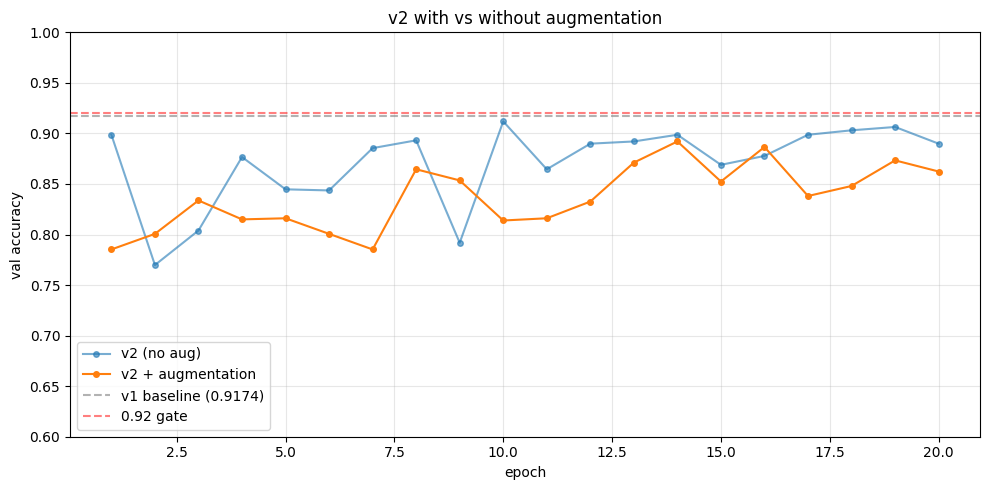

In [8]:
best_path_v2aug = os.path.join(CHECKPOINT_DIR, "pointnet_v2_aug_best.pt")

# Fresh model + optimizer
model = PointNetV2(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 20
history_v2aug = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc_v2aug = 0.0

print(f"Training PointNet v2 + augmentation -- {NUM_EPOCHS} epochs on {device}")
print(f"Augmentations: random z-rotation + per-point jitter (sigma=0.02, clip=0.05)\n")
print(f"{'epoch':>5}  {'train_loss':>11}  {'train_acc':>10}  {'val_acc':>9}  {'time':>7}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader:
        pts, lbls = pts.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(pts)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * pts.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += pts.size(0)
    train_loss = loss_sum / total
    train_acc  = correct  / total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for pts, lbls in test_loader:
            pts, lbls = pts.to(device), lbls.to(device)
            val_correct += (model(pts).argmax(1) == lbls).sum().item()
            val_total   += pts.size(0)
    val_acc = val_correct / val_total

    history_v2aug["train_loss"].append(train_loss)
    history_v2aug["train_acc"].append(train_acc)
    history_v2aug["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc_v2aug:
        best_val_acc_v2aug = val_acc
        torch.save(model.state_dict(), best_path_v2aug)
        flag = "  *"

    print(f"{epoch:>5}  {train_loss:>11.4f}  {train_acc:>10.4f}  {val_acc:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\n=== Three-way comparison ===")
print(f"  v1 baseline          best val_acc: 0.9174")
print(f"  v1 + augmentation    best val_acc: 0.8943   (Δ -0.0231)")
print(f"  v2 (+ T-Net)         best val_acc: 0.9119   (Δ -0.0055)")
print(f"  v2 + augmentation    best val_acc: {best_val_acc_v2aug:.4f}   (Δ {best_val_acc_v2aug - 0.9174:+.4f})")
print(f"\nCheckpoint: {best_path_v2aug}")

# Plot all four runs together if we kept the history dicts; otherwise just v2+aug
fig, ax = plt.subplots(figsize=(10, 5))
ep = range(1, NUM_EPOCHS + 1)
ax.plot(ep, history_v2["val_acc"],    "-o", markersize=4, label="v2 (no aug)", alpha=0.6)
ax.plot(ep, history_v2aug["val_acc"], "-o", markersize=4, label="v2 + augmentation")
ax.axhline(0.9174, color="gray", linestyle="--", alpha=0.6, label="v1 baseline (0.9174)")
ax.axhline(0.92,   color="red",  linestyle="--", alpha=0.5, label="0.92 gate")
ax.set(xlabel="epoch", ylabel="val accuracy", title="v2 with vs without augmentation", ylim=(0.6, 1.0))
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## Per-class evaluation of v2 + augmentation

OVERALL METRICS -- v2 + augmentation
  Accuracy     : 0.8921   (v1: 0.9174,  v2: 0.9119,  Δ vs v1: -0.0253)
  Macro F1     : 0.8834   (v1: 0.9125,  v2: 0.9096)
  Weighted F1  : 0.8906   (v1: 0.9183,  v2: 0.9111)

PER-CLASS METRICS
              precision    recall  f1-score   support

     bathtub     1.0000    0.7200    0.8372        50
         bed     0.9065    0.9700    0.9372       100
       chair     0.9083    0.9900    0.9474       100
        desk     0.8971    0.7093    0.7922        86
     dresser     0.7037    0.8837    0.7835        86
     monitor     0.9787    0.9200    0.9485       100
 night_stand     0.8472    0.7093    0.7722        86
        sofa     0.9596    0.9500    0.9548       100
       table     0.8571    0.9600    0.9057       100
      toilet     0.9417    0.9700    0.9557       100

    accuracy                         0.8921       908
   macro avg     0.9000    0.8782    0.8834       908
weighted avg     0.8984    0.8921    0.8906       908

CLASS COVE

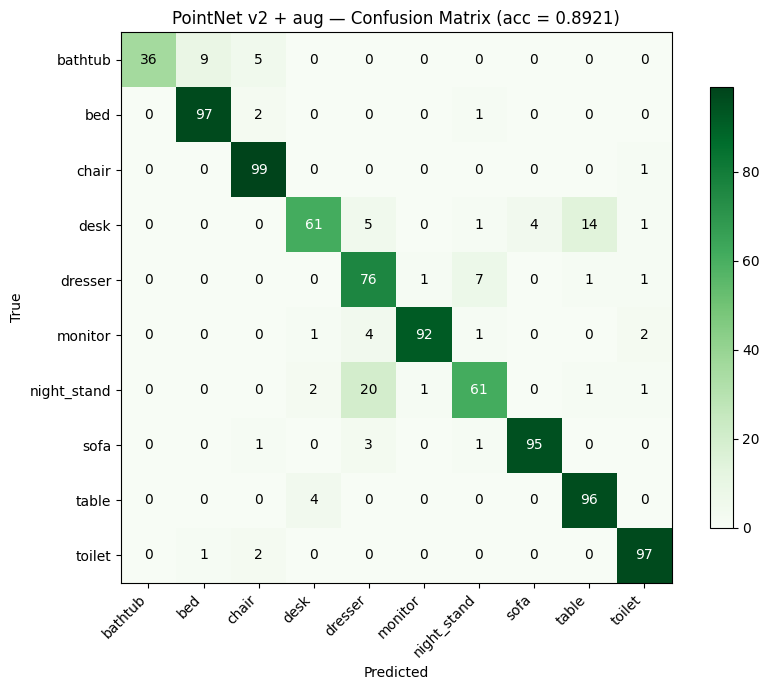

In [9]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_recall_fscore_support,
)

# Load best v2+aug checkpoint
model = PointNetV2(num_classes=10).to(device)
model.load_state_dict(torch.load(best_path_v2aug, map_location=device, weights_only=True))
model.eval()

# Inference on full test set
all_preds, all_labels = [], []
with torch.no_grad():
    for pts, lbls in test_loader:
        pts = pts.to(device)
        preds = model(pts).argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(lbls.numpy())
all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# ---- 1. Overall metrics ----
acc         = accuracy_score(all_labels, all_preds)
macro_f1    = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("=" * 60)
print("OVERALL METRICS -- v2 + augmentation")
print("=" * 60)
print(f"  Accuracy     : {acc:.4f}   (v1: 0.9174,  v2: 0.9119,  Δ vs v1: {acc - 0.9174:+.4f})")
print(f"  Macro F1     : {macro_f1:.4f}   (v1: 0.9125,  v2: 0.9096)")
print(f"  Weighted F1  : {weighted_f1:.4f}   (v1: 0.9183,  v2: 0.9111)")

# ---- 2. Per-class table ----
print("\n" + "=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

# ---- 3. Class coverage check ----
predicted_classes = set(all_preds.tolist())
missing = set(range(10)) - predicted_classes
print("=" * 60)
print("CLASS COVERAGE CHECK")
print("=" * 60)
print(f"  Distinct classes predicted: {len(predicted_classes)}/10")
if missing:
    print(f"  MISSING: {[CLASSES[i] for i in sorted(missing)]}")
    print(f"  GATE FAILED")
else:
    print(f"  GATE PASSED")

# ---- 4. THREE-WAY per-class F1 comparison: v1 vs v2 vs v2+aug ----
v1_f1 = {
    "bathtub": 0.8750, "bed": 0.9043, "chair": 0.9900, "desk": 0.8712,
    "dresser": 0.8324, "monitor": 0.9796, "night_stand": 0.7933,
    "sofa": 0.9899, "table": 0.9048, "toilet": 0.9848,
}
v2_f1 = {
    "bathtub": 0.9703, "bed": 0.9659, "chair": 0.9849, "desk": 0.7442,
    "dresser": 0.8478, "monitor": 0.9751, "night_stand": 0.8193,
    "sofa": 0.9709, "table": 0.8324, "toilet": 0.9848,
}
_, _, v2aug_f1_array, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=list(range(10)), zero_division=0
)

print("\n" + "=" * 60)
print("PER-CLASS F1 — v1 -> v2 -> v2+aug")
print("=" * 60)
print(f"  {'class':<14}{'v1':>8}{'v2':>8}{'v2+aug':>9}{'Δ vs v1':>10}{'Δ vs v2':>10}")
print(f"  {'-'*59}")
for i, c in enumerate(CLASSES):
    f1_v2aug = v2aug_f1_array[i]
    d_v1 = f1_v2aug - v1_f1[c]
    d_v2 = f1_v2aug - v2_f1[c]
    print(f"  {c:<14}{v1_f1[c]:>8.4f}{v2_f1[c]:>8.4f}{f1_v2aug:>9.4f}{d_v1:>+10.4f}{d_v2:>+10.4f}")

# ---- 5. Confusion matrix (Greens cmap so it's visually distinct from v1/v2 matrices) ----
cm = confusion_matrix(all_labels, all_preds, labels=list(range(10)))
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"PointNet v2 + aug — Confusion Matrix (acc = {acc:.4f})")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()